<a href="https://colab.research.google.com/github/foxel03/Notes-2-01/blob/main/00_Assignments/ps03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PS03 - Classification
DS325, Gettysburg College  
Prof Eatai Roth


Due Monday Mar 30, 2026 at 9a

Total pts: 20

There will be a quiz on Logistic Regression, including this homework on Thursday April 2.

**Your Name**:

**Your Collaborators**:

## IMPORTANT INSTRUCTIONS:

 - When you submit your code, make sure that every cell runs without returning an error.
 - Once you have the results you need, edit out any extraneous code and outputs.

## Problem 1

Churn is the term service companies use to describe customers that leave the platform (e.g. switching from Verizon to T-Mobile).  In this problem, you will be developing a classifier to predict customers at risk of churn from an Iranian Telecom service. The data come from the [UC Irvine ML repository](https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset).

Fit a LogisticRegression model to the data:
 - split your data into training and testing sets (split 70-30 train-test)
 - scale the feature data
 - fit your model. Use some form of regularization and try several values of regularization strength (C) using LogisticRegressionCV.
 - use the model to make predictions.
 - plot the confusion matrix of the training and test set side by side0
 - print the classification report of the test set.


Then, answer the question below.

In [1]:
#%%capture
#!pip install ucimlrepo

# You only need to run this cell once.
# If the package is installed successfully,
# re-comment out the line below to never run this cell again.

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

# fetch dataset
iranian_churn = fetch_ucirepo(id=563)

# data (as pandas dataframes)
X = iranian_churn.data.features
y = iranian_churn.data.targets

In [12]:
#Splitting Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

#scaling the featured data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
z_train = sc.fit_transform(X_train)
z_test = sc.transform(X_test)

In [13]:
# Create and fit the model
from sklearn.linear_model import LogisticRegressionCV
logreg = LogisticRegressionCV(Cs = [0.01, 0.1, 1, 10, 100], cv = 5, max_iter = 1000)
logreg.fit(z_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegressionCV(Cs=[0.01, 0.1, 1, 10, 100], cv=5, max_iter=1000)

In [14]:
import numpy as np
feature_names = list(X.columns)

coefs = logreg.coef_.flatten()

idx = np.argsort(np.abs(coefs))

for i in idx[::-1]:
    print(f'{feature_names[i]:<30}\t{coefs[i]:+0.2f}')

Complains                     	+0.67
Status                        	+0.51
Frequency of use              	-0.31
Distinct Called Numbers       	-0.29
Customer Value                	-0.27
Frequency of SMS              	-0.24
Seconds of Use                	-0.23
Call  Failure                 	+0.18
Charge  Amount                	-0.15
Subscription  Length          	-0.12
Tariff Plan                   	-0.09
Age Group                     	-0.05
Age                           	-0.02


In [15]:
print(logreg.C_)

[0.01]


In [17]:
#logreg.__dict__

In [18]:
#predicitions
y_pred_train = logreg.predict(z_train)
y_pred_test = logreg.predict(z_test)

#probabilities
y_prob_train = logreg.predict_proba(Z_train)
y_prob_test = logreg.predict_proba(Z_test)

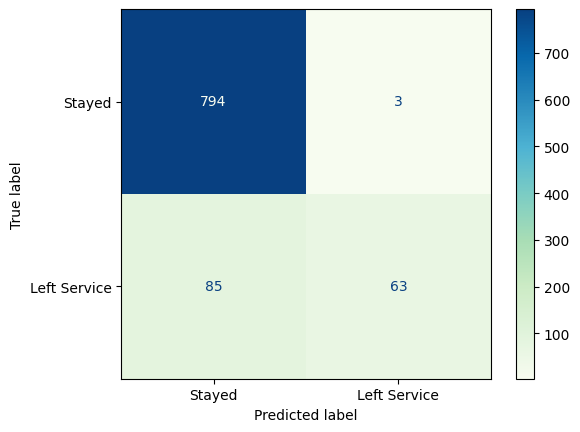

[0 1]


In [24]:
#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels = ['Stayed', 'Left Service'], cmap = 'GnBu')
plt.show()

In [25]:
#Classification report
from sklearn.metrics import classification_report
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve

cr = classification_report(y_test, y_pred_test, target_names = ['Stayed', 'Left Service'])
print(cr)

              precision    recall  f1-score   support

      Stayed       0.90      1.00      0.95       797
Left Service       0.95      0.43      0.59       148

    accuracy                           0.91       945
   macro avg       0.93      0.71      0.77       945
weighted avg       0.91      0.91      0.89       945



**Questions**

 - What regularization did you use and with what value of C?
   -  The penality is 'penalty': 'l2', so that would be the ridge penalty
   -  The chose C was 0.01

 - Which were the three most informative features?
   - Complains (+0.67)
   - Status	(+0.51)
   - Frequency of use (-0.31)

 - What were the Recall, Precision, and Accuracy of your algorithm?
   - Recall: 0.43  
   - Precision: 0.95
   - Accuracy: 0.91
 - Which metric is most useful for this problem? Why?
   - The goal is identify those who leave the service (churners), so recall would be the most important metric for this problem as it measures how many of the actual positive cases the model correctly identifies. However, this model kind of sucks at the most important thing.
 - Suppose your algorithm could predict churn 2 months before it happened. How might the company act on these predictions?
   - It would start hammering the customer with discounts, rewards, poersonalized outreach, improved service, etc.
   - It would basically do everything it can to not the let the customer reach a place of wanting to leave the service.
  


## Problem 2

In this exercise, you'll compare three models and how they classify a synthetic dataset, nested moons.

Fit the following models:

  - Plain LogisticRegression
  - LogisticRegression with polynomial features (up to degree 5)
  - LogisticRegression with polynomial features (up to degree 5) with Lasso
  
  Make each model as good as possible.

For each model:

  - plot the confusion matrix
  - print the classification report
  - plot the decision boundaries

For a classification problem with 2 features, we can plot the decision boundary separating the regions of the plane into those that map to each category. For each model, plot the decision boundary plot along with the data points from the test set.   
**You may use co-pilot/ChatGPT to create the DecisionBoundary plots.**

Then answer the questions below.
  

In [ ]:
from sklearn.datasets import make_moons

import matplotlib.pyplot as plt
import matplotlib as mpl

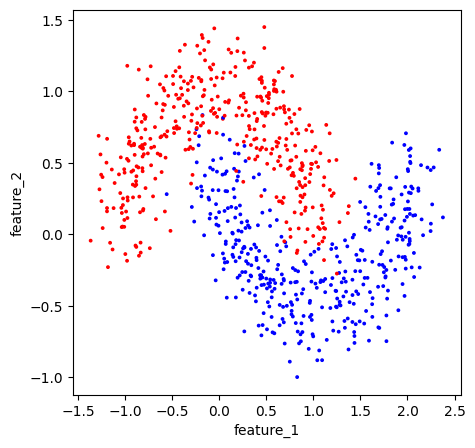

In [ ]:
df = pd.DataFrame()
df[['feature_1','feature_2']], df['y'] = make_moons(n_samples=800, noise=.2, random_state=1)


fig, ax = plt.subplots(1,1, figsize=(5,5))

cmap = mpl.colors.ListedColormap(['red', 'blue'])    # Training Data
df.plot(x = 'feature_1', y = 'feature_2', c = 'y',
        s = 3, colorbar = False,
        kind = 'scatter', cmap = cmap,
        ax = ax)

plt.show()


**Questions**

 - What are the Accuracy scores for each model?
   - Logistic
   - Logistic with Polynomial
   - Logistic with Polynomial and Lasso
 - Describe the decision boundaries for each?
   - Logistic
   - Logistic with Polynomial
   - Logistic with Polynomial and Lasso
 - Based on the decision boundaries and the confusion matrices, state which models are over- or under-fitting if any.
   - Logistic
   - Logistic with Polynomial
   - Logistic with Polynomial and Lasso